# Surface Brightness Profiles of the Mirror Galaxy

In this notebook, we're going to use the cleaned images from the first tutorial to measure radial surface brightness profiles for NGC 4321. Briefly, we'll:

1. Load the background-subtracted images. 
2. Make cutouts centered on NGC 4321 using `Cutout2D`. 
3. Measure circular radial surface brightness profiles in every image. 
4. Convert the data from Jy/pixel to Jy/arcsec<sup>2</sup> and mag/arcsect<sup>2</sup>. 
5. Fit each profile with a bulge+disk model. 
6. Plot the data, bulge model, disk model, and total model. 
7. Save the profile measurements and fitted parameters. 

### What is a *surface brightness profile*? 

This is a measure of how a galaxy's brightness changes with radius. *Surface brightness* is a measure of how much light is being emitted per unit area. Hopefully, you're familiar with the concept of total magnitude; this is the total amount of light an object emitted summed over its entire area and expressed in the archaic magnitude system. Importantly, the total magnitude has the light from the background sky subtracted out. 

When we talk about a galaxy having a magnitude of 12.5, for example, that means that it has the same brightness as a star of the same magnitude. However, stars are so small that they are effectively point sources, i.e., they don't have an area to them. However, despite galaxies being much further away, they are so large that they *do* have an area to them. This means that their light is spread out, diminishing their apparent brightness. It is usually better to talk about a galaxy's surface brightness in magnitudes per square arcsecond (mag/arcsec<sup>2</sup>) than its total magnitude. 

However, a galaxy emits different amounts of light across its surface. The centers of galaxies are usually bright (a lot of stars are concentrated there!) and get progressively dimmer as we move away from the center. Functionally, we describe this profile as a Sérsic profile: $$I(r) = I_0 \exp\left(-kr^{1/n}\right),$$ where $I_0$ is the intensity at the center ($r=0$) and $n$ is the Sérsic index: the smaller the value of $n$, the less centrally concentrated the profile will be. We can rewrite this equation in a more common form: $$I(r) = I_e \exp\left( -b_n \left[\left(\frac{r}{R_e}\right)^{1/n} - 1\right] \right),$$ where $R_e$ is the half-light radius and $I_e$ is the intensity at that radius. (We'll see what $b_n$ equals later.)

Thankfully, most galaxies are not this complicated. It turns out that most galaxies have a Sérsic index in the range $0.5 < n < 10$. For elliptical galaxies and the bulges of spiral galaxies, $n$ is usually around 4, resulting in the de Vaucouleurs profile: $$I(r) \propto e^{-kr^{1/4}}.$$ For the disks of spiral galaxies, $n$ is usually around 1, resulting in an exponential profile: $$I(r) \propto e^{-kr}.$$

Now, these are simplified models. Galaxies are not smooth disks of light. They have spiral arms, bars, rings, dust lanes, star-forming regions, etc., all of which can result in bumps and wiggles in their surface brightness profile. But these simple models are usually a good first step. 

With that out of the way, let's get started!

In [1]:
# Numerical tools
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# File paths
from pathlib import Path

# FITS, WCS, coordinates, units, tables
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table, vstack

# Cutouts
from astropy.nddata import Cutout2D

# Image display scaling
from astropy.visualization import ImageNormalize, PercentileInterval, AsinhStretch

# Fitting tools
from scipy.optimize import curve_fit
from scipy.special import gammainccinv, gamma

# Plot defaults
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

## 1. Define the Galaxy and Images

We'll begin by defining the position of NGC 4321 and the list of images we want to process. Since each image was created in the last tutorial, we know exactly what each image contains: 
- the final background-subtracted science image
- the background, calibration, and total uncertainties

Since these images are from DustPedia, the image units are in jansky per pixel (Jy/pix). 

In [5]:
# Directory created by the first notebook
processed_dir = Path('NGC4321_BkgSub')

# Directory for products from this notebook
output_dir = Path('NGC4321_Profiles')
output_dir.mkdir(exist_ok=True)

# Center of NGC 4321
target_name = 'NGC4321'
target_coord = SkyCoord(ra=185.728590*u.deg, dec=15.821635*u.deg, frame='icrs')

# AB zero-point flux density
AB_ZEROPOINT_JY = 3631.0

# Table for the image files
image_table = Table(
    names=['band','instrument','wavelength_um','psf_fwhm_arcsec','filename','usable','notes'],
    dtype=['U20','U20',float,float,'U200',bool,'U100']
)

# GALEX
image_table.add_row(('FUV', 'GALEX', 0.153508, 4.3, str(processed_dir / 'NGC4321_GALEX_FUV_bkgsub.fits'), True, 'Far-UV: young massive stars'))
image_table.add_row(('NUV', 'GALEX', 0.230078, 5.3, str(processed_dir / 'NGC4321_GALEX_NUV_bkgsub.fits'), True, 'Near-UV: recent star formation'))

# SDSS
image_table.add_row(('u', 'SDSS', 0.350102, 1.3, str(processed_dir / 'NGC4321_SDSS_u_bkgsub.fits'), True, 'Blue optical / young stars'))
image_table.add_row(('g', 'SDSS', 0.476311, 1.3, str(processed_dir / 'NGC4321_SDSS_g_bkgsub.fits'), True, 'Optical stellar light'))
image_table.add_row(('r', 'SDSS', 0.624698, 1.3, str(processed_dir / 'NGC4321_SDSS_r_bkgsub.fits'), True, 'Optical stellar light'))
image_table.add_row(('i', 'SDSS', 0.771828, 1.3, str(processed_dir / 'NGC4321_SDSS_i_bkgsub.fits'), True, 'Older stars, less dust-sensitive'))
image_table.add_row(('z', 'SDSS', 1.082983, 1.3, str(processed_dir / 'NGC4321_SDSS_z_bkgsub.fits'), True, 'Red optical / old stars'))

# 2MASS
image_table.add_row(('J', '2MASS', 1.235000, 2.0, str(processed_dir / 'NGC4321_2MASS_J_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))
image_table.add_row(('H', '2MASS', 1.662000, 2.0, str(processed_dir / 'NGC4321_2MASS_H_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))
image_table.add_row(('Ks', '2MASS', 2.159000, 2.0, str(processed_dir / 'NGC4321_2MASS_Ks_bkgsub.fits'), True, 'Near-IR stellar mass tracer'))

# Spitzer
image_table.add_row(('IRAC1', 'Spitzer', 3.537841, 1.66, str(processed_dir / 'NGC4321_Spitzer_IRAC1_bkgsub.fits'), True, 'Old stars + hot dust'))
image_table.add_row(('IRAC2', 'Spitzer', 4.478049, 1.72, str(processed_dir / 'NGC4321_Spitzer_IRAC2_bkgsub.fits'), True, 'Old stars + hot dust'))
image_table.add_row(('IRAC3', 'Spitzer', 5.696178, 1.88, str(processed_dir / 'NGC4321_Spitzer_IRAC3_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('IRAC4', 'Spitzer', 7.797840, 1.98, str(processed_dir / 'NGC4321_Spitzer_IRAC4_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('MIPS24', 'Spitzer', 23.593478, 6.0, str(processed_dir / 'NGC4321_Spitzer_MIPS24_bkgsub.fits'), True, 'Warm dust + embedded star formation'))
image_table.add_row(('MIPS160', 'Spitzer', 155.000000, 38.0, str(processed_dir / 'NGC4321_Spitzer_MIPS160_bkgsub.fits'), True, 'Cold dust'))

# WISE
image_table.add_row(('W1', 'WISE', 3.352600, 6.1, str(processed_dir / 'NGC4321_WISE_W1_bkgsub.fits'), True, 'Old stars'))
image_table.add_row(('W2', 'WISE', 4.602800, 6.4, str(processed_dir / 'NGC4321_WISE_W2_bkgsub.fits'), True, 'Old stars + dust'))
image_table.add_row(('W3', 'WISE', 11.560800, 6.5, str(processed_dir / 'NGC4321_WISE_W3_bkgsub.fits'), True, 'PAH + warm dust'))
image_table.add_row(('W4', 'WISE', 22.088300, 12.0, str(processed_dir / 'NGC4321_WISE_W4_bkgsub.fits'), True, 'Warm dust + star formation'))

# Keep only the rows we want to process.
image_table = image_table[image_table['usable']]

image_table

band,instrument,wavelength_um,psf_fwhm_arcsec,filename,usable,notes
str20,str20,float64,float64,str200,bool,str100
FUV,GALEX,0.153508,4.3,NGC4321_BkgSub/NGC4321_GALEX_FUV_bkgsub.fits,True,Far-UV: young massive stars
NUV,GALEX,0.230078,5.3,NGC4321_BkgSub/NGC4321_GALEX_NUV_bkgsub.fits,True,Near-UV: recent star formation
u,SDSS,0.350102,1.3,NGC4321_BkgSub/NGC4321_SDSS_u_bkgsub.fits,True,Blue optical / young stars
g,SDSS,0.476311,1.3,NGC4321_BkgSub/NGC4321_SDSS_g_bkgsub.fits,True,Optical stellar light
r,SDSS,0.624698,1.3,NGC4321_BkgSub/NGC4321_SDSS_r_bkgsub.fits,True,Optical stellar light
i,SDSS,0.771828,1.3,NGC4321_BkgSub/NGC4321_SDSS_i_bkgsub.fits,True,"Older stars, less dust-sensitive"
z,SDSS,1.082983,1.3,NGC4321_BkgSub/NGC4321_SDSS_z_bkgsub.fits,True,Red optical / old stars
J,2MASS,1.235,2.0,NGC4321_BkgSub/NGC4321_2MASS_J_bkgsub.fits,True,Near-IR stellar mass tracer
H,2MASS,1.662,2.0,NGC4321_BkgSub/NGC4321_2MASS_H_bkgsub.fits,True,Near-IR stellar mass tracer


## 2. Load the Images

Now that we know which images were using, we've got to load them in as well as their uncertainties. The science image has already been corrected for Milky Way foreground extinction and background-subtracted. For the uncertainties, we'll use the background uncertainty image `SIGMA_BKG` plus the calibration uncertainty from the FITS header. This is better than using the total uncertainty we saved since the calibration uncertainty is systematic across the image but the background uncertainty is pixel-by-pixel. 

In [6]:
# Dictionaries to hold images
images = {}
sigma_bkg_images = {}
sigma_total_images = {}
final_masks = {}
headers = {}
wcs_dict = {}
calibration_percent = {}

for row in image_table:
    band = row['band']
    filename = row['filename']

    print(f'Loading {band:8s} from {filename}...')

    with fits.open(filename) as hdul:
        # Science image
        science_data = np.squeeze(hdul[0].data).astype(float)
        header = hdul[0].header.copy()

        # WCS from the primary header
        wcs = WCS(header).celestial

        # Background uncertainty
        if 'SIGMA_BKG' in hdul:
            sigma_bkg = np.squeeze(hdul['SIGMA_BKG'].data).astype(float)
        elif 'BACKGROUND_RMS' in hdul:
            sigma_bkg = np.squeeze(hdul['BACKGROUND_RMS'].data).astype(float)
        else:
            raise ValueError(f'No SIGMA_BKG or BACKGROUND_RMS extension found for {band}.')
    
        # Total uncertainty
        if 'SIGMA_TOTAL' in hdul:
            sigma_total = np.squeeze(hdul['SIGMA_TOTAL'].data).astype(float)
        else:
            sigma_total = np.full_like(science_data, np.nan)

        # Masks
        mask = ~np.isfinite(science_data)
    
    images[band] = science_data
    sigma_bkg_images[band] = sigma_bkg
    sigma_total_images[band] = sigma_total
    final_masks[band] = mask
    headers[band] = header
    wcs_dict[band] = wcs

    # Calibration uncertainty percentage
    calibration_percent[band] = header.get('CALPCT', np.nan)

print('\nLoaded bands:')
print(list(images.keys()))

Loading FUV      from NGC4321_BkgSub/NGC4321_GALEX_FUV_bkgsub.fits...
Loading NUV      from NGC4321_BkgSub/NGC4321_GALEX_NUV_bkgsub.fits...
Loading u        from NGC4321_BkgSub/NGC4321_SDSS_u_bkgsub.fits...
Loading g        from NGC4321_BkgSub/NGC4321_SDSS_g_bkgsub.fits...
Loading r        from NGC4321_BkgSub/NGC4321_SDSS_r_bkgsub.fits...
Loading i        from NGC4321_BkgSub/NGC4321_SDSS_i_bkgsub.fits...
Loading z        from NGC4321_BkgSub/NGC4321_SDSS_z_bkgsub.fits...
Loading J        from NGC4321_BkgSub/NGC4321_2MASS_J_bkgsub.fits...
Loading H        from NGC4321_BkgSub/NGC4321_2MASS_H_bkgsub.fits...
Loading Ks       from NGC4321_BkgSub/NGC4321_2MASS_Ks_bkgsub.fits...
Loading IRAC1    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC1_bkgsub.fits...
Loading IRAC2    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC2_bkgsub.fits...
Loading IRAC3    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC3_bkgsub.fits...
Loading IRAC4    from NGC4321_BkgSub/NGC4321_Spitzer_IRAC4_bkgsub.fits...
Loading MIPS24   from NG

## 3. Make Cutouts Centered on NGC 4321

The original images cover very different and sometimes very large fields of view. Now that we've subtracted the background, we don't care much about most of the images, so we'll make cutouts centered on NGC 4321 to make our analysis easier. Doing this reduces memory usage, makes the plots easier to inspect, and lets us define a consistent radial range. 

We'll make the cutout large enough to include the galaxy and enough surrounding sky to inspect the outer reaches of the surface brightness profile. 

In [18]:
# Size of the square cutout
cutout_size = 14.0 * u.arcmin

cutout_images = {}
cutout_sigma_bkg = {}
cutout_masks = {}
cutout_wcs = {}
cutout_pixel_area_arcsec2 = {}
cutout_pixscale_arcsec = {}

for row in image_table:
    band = row['band']

    data = images[band]
    sigma_bkg = sigma_bkg_images[band]
    mask = final_masks[band].astype(float)
    wcs = wcs_dict[band]

    # Create a science-image cutout
    # mode='partial' means that the code will still return a cutout if
    # part of the region is outside the image footprint
    science_cutout = Cutout2D(
        data, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=np.nan, copy=True
    )

    # Create an uncertainty cutout
    sigma_cutout = Cutout2D(
        sigma_bkg, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=np.nan, copy=True
    )

    # Create a mask cutout
    mask_cutout = Cutout2D(
        mask, position=target_coord, size=cutout_size,
        wcs=wcs, mode='partial', fill_value=1.0, copy=True
    )

    cutout_images[band] = science_cutout.data
    cutout_sigma_bkg[band] = sigma_cutout.data
    cutout_masks[band] = mask_cutout.data.astype(bool)
    cutout_wcs[band] = science_cutout.wcs

    # Estimate pixel scale and pixel area for each cutout
    # The image units are in Jy/pixel, so dividing by pixel area gives Jy/arcsec^2
    pixscale = np.mean(proj_plane_pixel_scales(wcs)) * u.deg
    pixscale_arcsec = pixscale.to(u.arcsec).value

    pixel_area_arcsec2 = pixscale_arcsec**2
    mean_pixscale_arcsec = np.sqrt(pixel_area_arcsec2)

    cutout_pixel_area_arcsec2[band] = pixel_area_arcsec2
    cutout_pixscale_arcsec[band] = mean_pixscale_arcsec

print('Created cutouts.')

Created cutouts.


## 4. Inspect the Cutouts

Hopefully you know by now that we should always inspect the images!! 

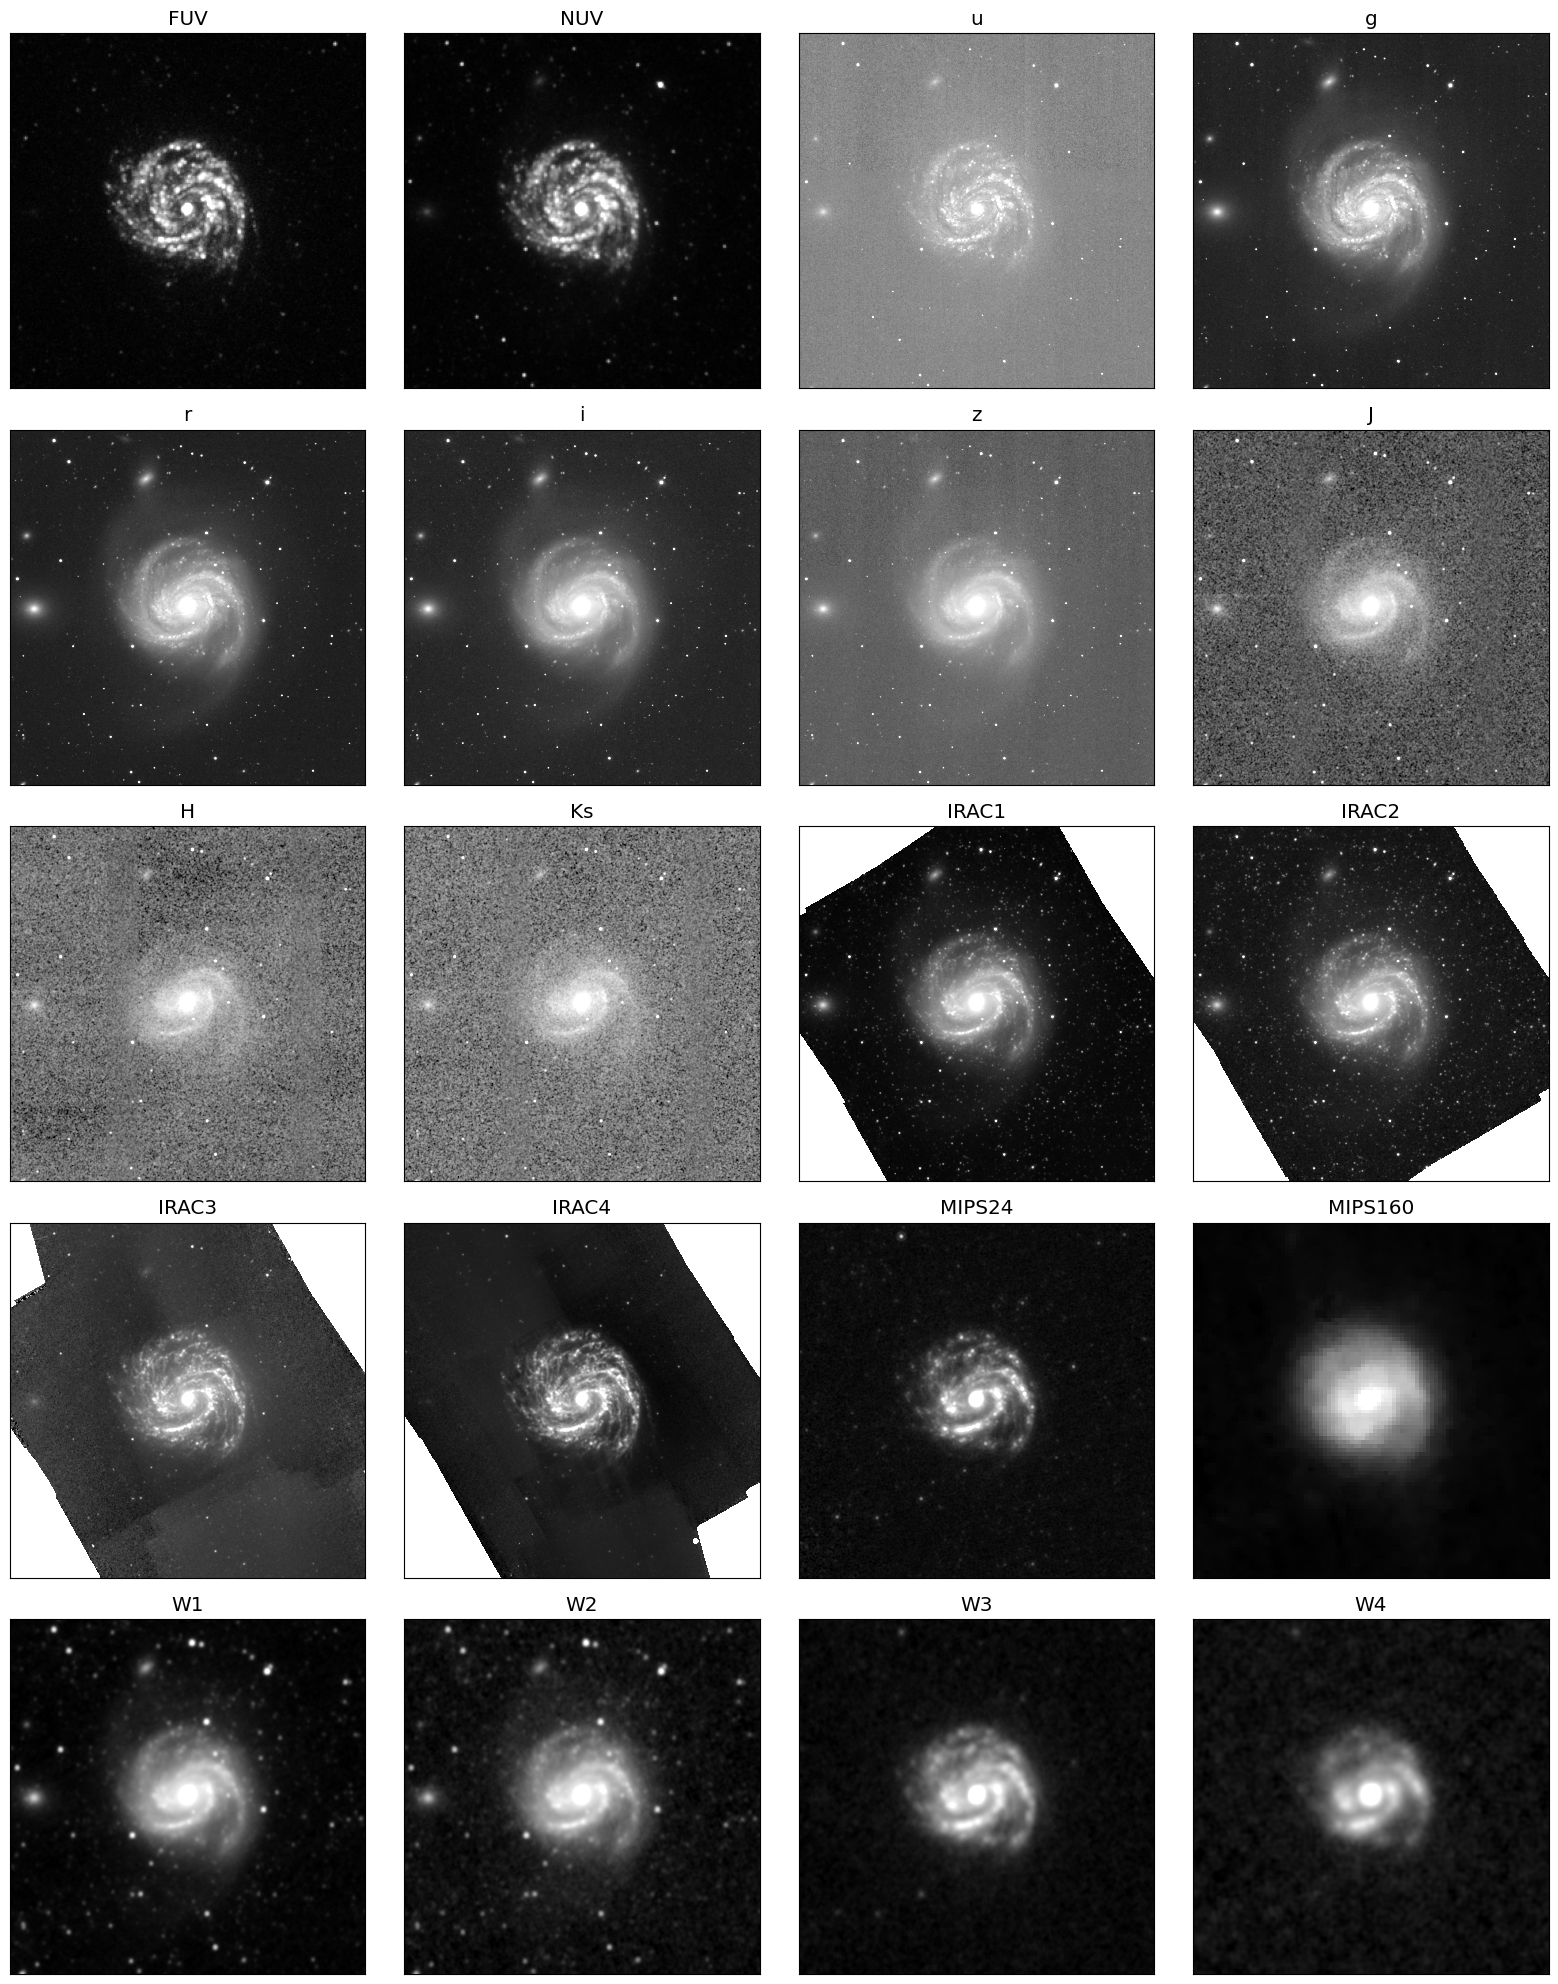

In [11]:
sorted_bands = list(image_table['band'])

n_images = len(sorted_bands)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows))
axes = np.ravel(axes)

for ax, band in zip(axes, sorted_bands):
    data = cutout_images[band]

    norm = ImageNormalize(
        data, interval=PercentileInterval(99.5), stretch=AsinhStretch()
    )

    ax.imshow(data, origin='lower', cmap='gray', norm=norm)
    ax.set_title(f'{band}')
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes[n_images:]:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 5. Surface Brightness Units

Our images are in Jy/pix. But a surface brightness is a flux per unit angular area, so we need to convert from Jy/pix to Jy/arcsec<sup>2</sup>: $$I_\nu = \frac{F_\nu}{A_{\rm pix}},$$ where $A_{\rm pix}$ is the pixeal area in arcsec<sup>2</sup>. 

We also need to convert into mag/arcsec<sup>2</sup> using $$\mu = -2.5\log\left(\frac{I_\nu}{3631~{\rm Jy~arcsec^{-2}}}\right).$$ 

In [19]:
# Display pixel scales and pixel areas for each band
pixel_table = Table(
    names=['band', 'pixel_scale_arcsec', 'pixel_area_arcsec2'],
    dtype=['U20', float, float]
)

for band in sorted_bands:
    pixel_table.add_row(
        (
            band,
            cutout_pixscale_arcsec[band],
            cutout_pixel_area_arcsec2[band]
        )
    )

pixel_table

band,pixel_scale_arcsec,pixel_area_arcsec2
str20,float64,float64
FUV,3.2000004,10.24000256000016
NUV,3.2000004,10.24000256000016
u,0.45,0.2025
g,0.45,0.2025
r,0.45,0.2025
i,0.45,0.2025
z,0.45,0.2025
J,1.0000008,1.00000160000064
H,1.0000008,1.00000160000064


## 6. Measure Circular Radial Profiles

We'll measure a circular profile in each band. For each annulus, we'll compute (1) the mean flux in Jy/pixel, (2) the uncertainty in the mean flux, (3), the surface brightness in Jy/arcsec<sup>2</sup>, and (4) the surface brightness in mag/arcsec<sup>2</sup>. The annulus width should be slightly larger than the PSF FWHM. This helps avoid oversampling the image more finely than the resolution of the data. 

For the uncertainty on the mean annular surface brightness, we include (1) a random background term, which decreases as more independent pixels are averaged; and (2) a calibration term, which does not average down in the same way. 

In [23]:
# Maximum radius for the profile
# This should be smaller than about half the cutout size
# 330 arcsec = 5.5 arcmin
max_profile_radius_arcsec = 330.0

# Minimum number of unmaked pixels required in an annulus
# If an annulus has too few pixels, the mean is not reliable
min_pixels_per_annulus = 20

# Tables for all bands will be collected here
profile_tables = []

for row in image_table:
    band = row['band']
    psf_fwhm = float(row['psf_fwhm_arcsec'])

    print(f'Measuring profile for {band}...')

    data = cutout_images[band]
    sigma_bkg = cutout_sigma_bkg[band]
    mask = cutout_masks[band]
    wcs = cutout_wcs[band]

    pixel_area = cutout_pixel_area_arcsec2[band]
    pixscale = cutout_pixscale_arcsec[band]

    # The radial bin width is at least slightly larger than the PWF FWHM
    # We also require it to be at least two pixels wide
    annulus_width_arcsec = max(1.25 * psf_fwhm, 2.0 * pixscale)

    # Radial bin edges in arcseconds
    radius_edges_arcsec = np.arange(
        0.0,
        max_profile_radius_arcsec + annulus_width_arcsec,
        annulus_width_arcsec
    )

    # Convert the target coordinate to pixel coordinates in the cutout
    x_center, y_center = wcs.world_to_pixel(target_coord)

    # Create a radius image
    # r_pix gives the distance of every pixel from the galaxy center in pixels
    yy, xx = np.indices(data.shape)
    r_pix = np.sqrt((xx - x_center)**2 + (yy - y_center)**2)

    # Convert pixel radius to arcsec
    r_arcsec = r_pix * pixscale
    # print(r_pix[50,50])

    # Calibration uncertainty as a fraction
    cal_percent = calibration_percent[band]

    if not np.isfinite(cal_percent):
        print(f'   WARNING: No CALPCT bound for {band}. Setting calibration uncertainty to 0.')
        cal_fraction = 0.0
    else:
        cal_fraction = cal_percent / 100.0
    
    # Create lists for the annular profile
    rows = []

    for i in range(len(radius_edges_arcsec) - 1):
        r_inner = radius_edges_arcsec[i]
        r_outer = radius_edges_arcsec[i + 1]
        r_mid = 0.5 * (r_inner + r_outer)

        # Select pixels in this annulus
        in_annulus = (r_arcsec >= r_inner) & (r_arcsec < r_outer)

        # Select pixels that are unmasked and finite
        good = (
            in_annulus & 
            (~mask) & 
            np.isfinite(data) & 
            np.isfinite(sigma_bkg)
        )

        n_pix = np.count_nonzero(good)

        if n_pix < min_pixels_per_annulus:
            mean_jy_pix = np.nan
            sigma_mean_jy_pix = np.nan
            sb_jy_arcsec2 = np.nan
            sigma_sb_jy_arcsec2 = np.nan
            mu_ab_arcsec2 = np.nan
            sigma_mu = np.nan
        else:
            values = data[good]
            sigma_values = sigma_bkg[good]

            # Mean flux per pixel in this annulus
            mean_jy_pix = np.nanmean(values)

            # Random uncertainty on the mean from background noise
            # For independent pixels: 
            #
            #       sigma_mean = sqrt(sum(sigma_i^2)) / N
            #
            # In reality, neighboring pixels are somewhat correlated by the PSF,
            # so this is an optimistic estimate
            sigma_random_mean_jy_pix = np.sqrt(np.nansum(sigma_values**2)) / n_pix

            # Calibration uncertainty on the annular mean
            # This scales with the measured flux and does not average down with it
            sigma_cal_mean_jy_pix = cal_fraction * np.abs(mean_jy_pix)

            # Total uncertainty on the annuluar mean
            sigma_mean_jy_pix = np.sqrt(
                sigma_random_mean_jy_pix**2 + sigma_cal_mean_jy_pix**2
            )

            # Convert Jy/pix to Jy/arcsec^2
            sb_jy_arcsec2 = mean_jy_pix / pixel_area
            sigma_sb_jy_arcsec2 = sigma_mean_jy_pix / pixel_area

            # Convert to mag/arcsec^2
            if sb_jy_arcsec2 > 0 and sigma_sb_jy_arcsec2 > 0:
                mu_ab_arcsec2 = -2.5 * np.log10(sb_jy_arcsec2 / AB_ZEROPOINT_JY)

                # Error propagation for mu = -2.5log(I / I0):
                # 
                #       sigma_mu = (2.5/ ln 10) * sigma_I / I
                sigma_mu = (2.5 / np.log(10)) * (
                    sigma_sb_jy_arcsec2 / sb_jy_arcsec2
                )
            else:
                mu_ab_arcsec2 = np.nan
                sigma_mu = np.nan
            
        rows.append(
            (
                band, r_inner, r_outer, r_mid, annulus_width_arcsec, n_pix, 
                mean_jy_pix, sigma_mean_jy_pix, sb_jy_arcsec2, sigma_sb_jy_arcsec2, 
                mu_ab_arcsec2, sigma_mu
            )
        )
    
    profile_table = Table(
        rows=rows,
        names=['band', 'r_inner_arcsec', 'r_outer_arcsec', 'r_mid_arcsec', 'annulus_width_arcsec', 
               'n_pix', 'mean_jy_pix', 'sigma_mean_jy_pix', 'sb_jy_arcsec2', 'sigma_sb_jy_arcsec2', 
               'mu_ab_arcsec2', 'sigma_mu_ab_arcsec2']
    )

    profile_tables.append(profile_table)

# Combine all individual band tables into one table
all_profiles = vstack(profile_tables)

all_profiles[:10]


Measuring profile for FUV...
Measuring profile for NUV...
Measuring profile for u...
Measuring profile for g...
Measuring profile for r...
Measuring profile for i...
Measuring profile for z...
Measuring profile for J...
Measuring profile for H...
Measuring profile for Ks...
Measuring profile for IRAC1...
Measuring profile for IRAC2...
Measuring profile for IRAC3...
Measuring profile for IRAC4...
Measuring profile for MIPS24...
Measuring profile for MIPS160...
Measuring profile for W1...
Measuring profile for W2...
Measuring profile for W3...
Measuring profile for W4...


band,r_inner_arcsec,r_outer_arcsec,r_mid_arcsec,annulus_width_arcsec,n_pix,mean_jy_pix,sigma_mean_jy_pix,sb_jy_arcsec2,sigma_sb_jy_arcsec2,mu_ab_arcsec2,sigma_mu_ab_arcsec2
str7,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64
FUV,0.0,6.4000008,3.2000004,6.4000008,12,nan,nan,nan,nan,nan,nan
FUV,6.4000008,12.8000016,9.6000012,6.4000008,39,4.6182228137318945e-05,2.078212544948336e-06,4.5099820890394605e-06,2.0295039310500948e-07,22.264628579475783,0.04885841788585326
FUV,12.8000016,19.2000024,16.000002,6.4000008,60,6.554462885895491e-06,2.9500705750346496e-07,6.40084106179695e-07,2.880927575700336e-08,24.384473013690318,0.04886744323168364
FUV,19.2000024,25.6000032,22.4000028,6.4000008,91,2.745667421834959e-06,1.2364351388931082e-07,2.6813151713068676e-07,1.20745588846131e-08,25.329195958534847,0.048893117369409045
FUV,25.6000032,32.000004,28.800003599999997,6.4000008,110,2.1075978135967194e-06,9.493724601255781e-08,2.0582004752903953e-07,9.271213113110425e-09,25.616346436896443,0.048907246207452515
FUV,32.000004,38.4000048,35.2000044,6.4000008,141,2.56623252062889e-06,1.1554157535082087e-07,2.506085819405156e-07,1.1283354147014888e-08,25.40257577461542,0.048883984792786064
FUV,38.4000048,44.8000056,41.6000052,6.4000008,162,3.5066874447360454e-06,1.5783986497835876e-07,3.4244986016253405e-07,1.541404546078124e-08,25.063573139271593,0.0488701826615284
FUV,44.8000056,51.2000064,48.000006,6.4000008,188,5.607865691138174e-06,2.5237493482802186e-07,5.476429969894545e-07,2.4645983567802732e-08,24.55382177608265,0.04886219089541765
FUV,51.2000064,57.6000072,54.4000068,6.4000008,213,8.589016401418093e-06,3.865178292461146e-07,8.387709232582417e-07,3.774587232584721e-08,24.090957205159995,0.048859657658557924


## 7. Plot the Measured Surface Brightness Profiles

Now we plot the measured surface brightness profiles before fitting. Since the $y$-axis is in mag/arcsec<sup>2</sup>, smaller values are brighter, so we need to flip the $y$-axis to put the brighter (less positive) numbers at the top. 

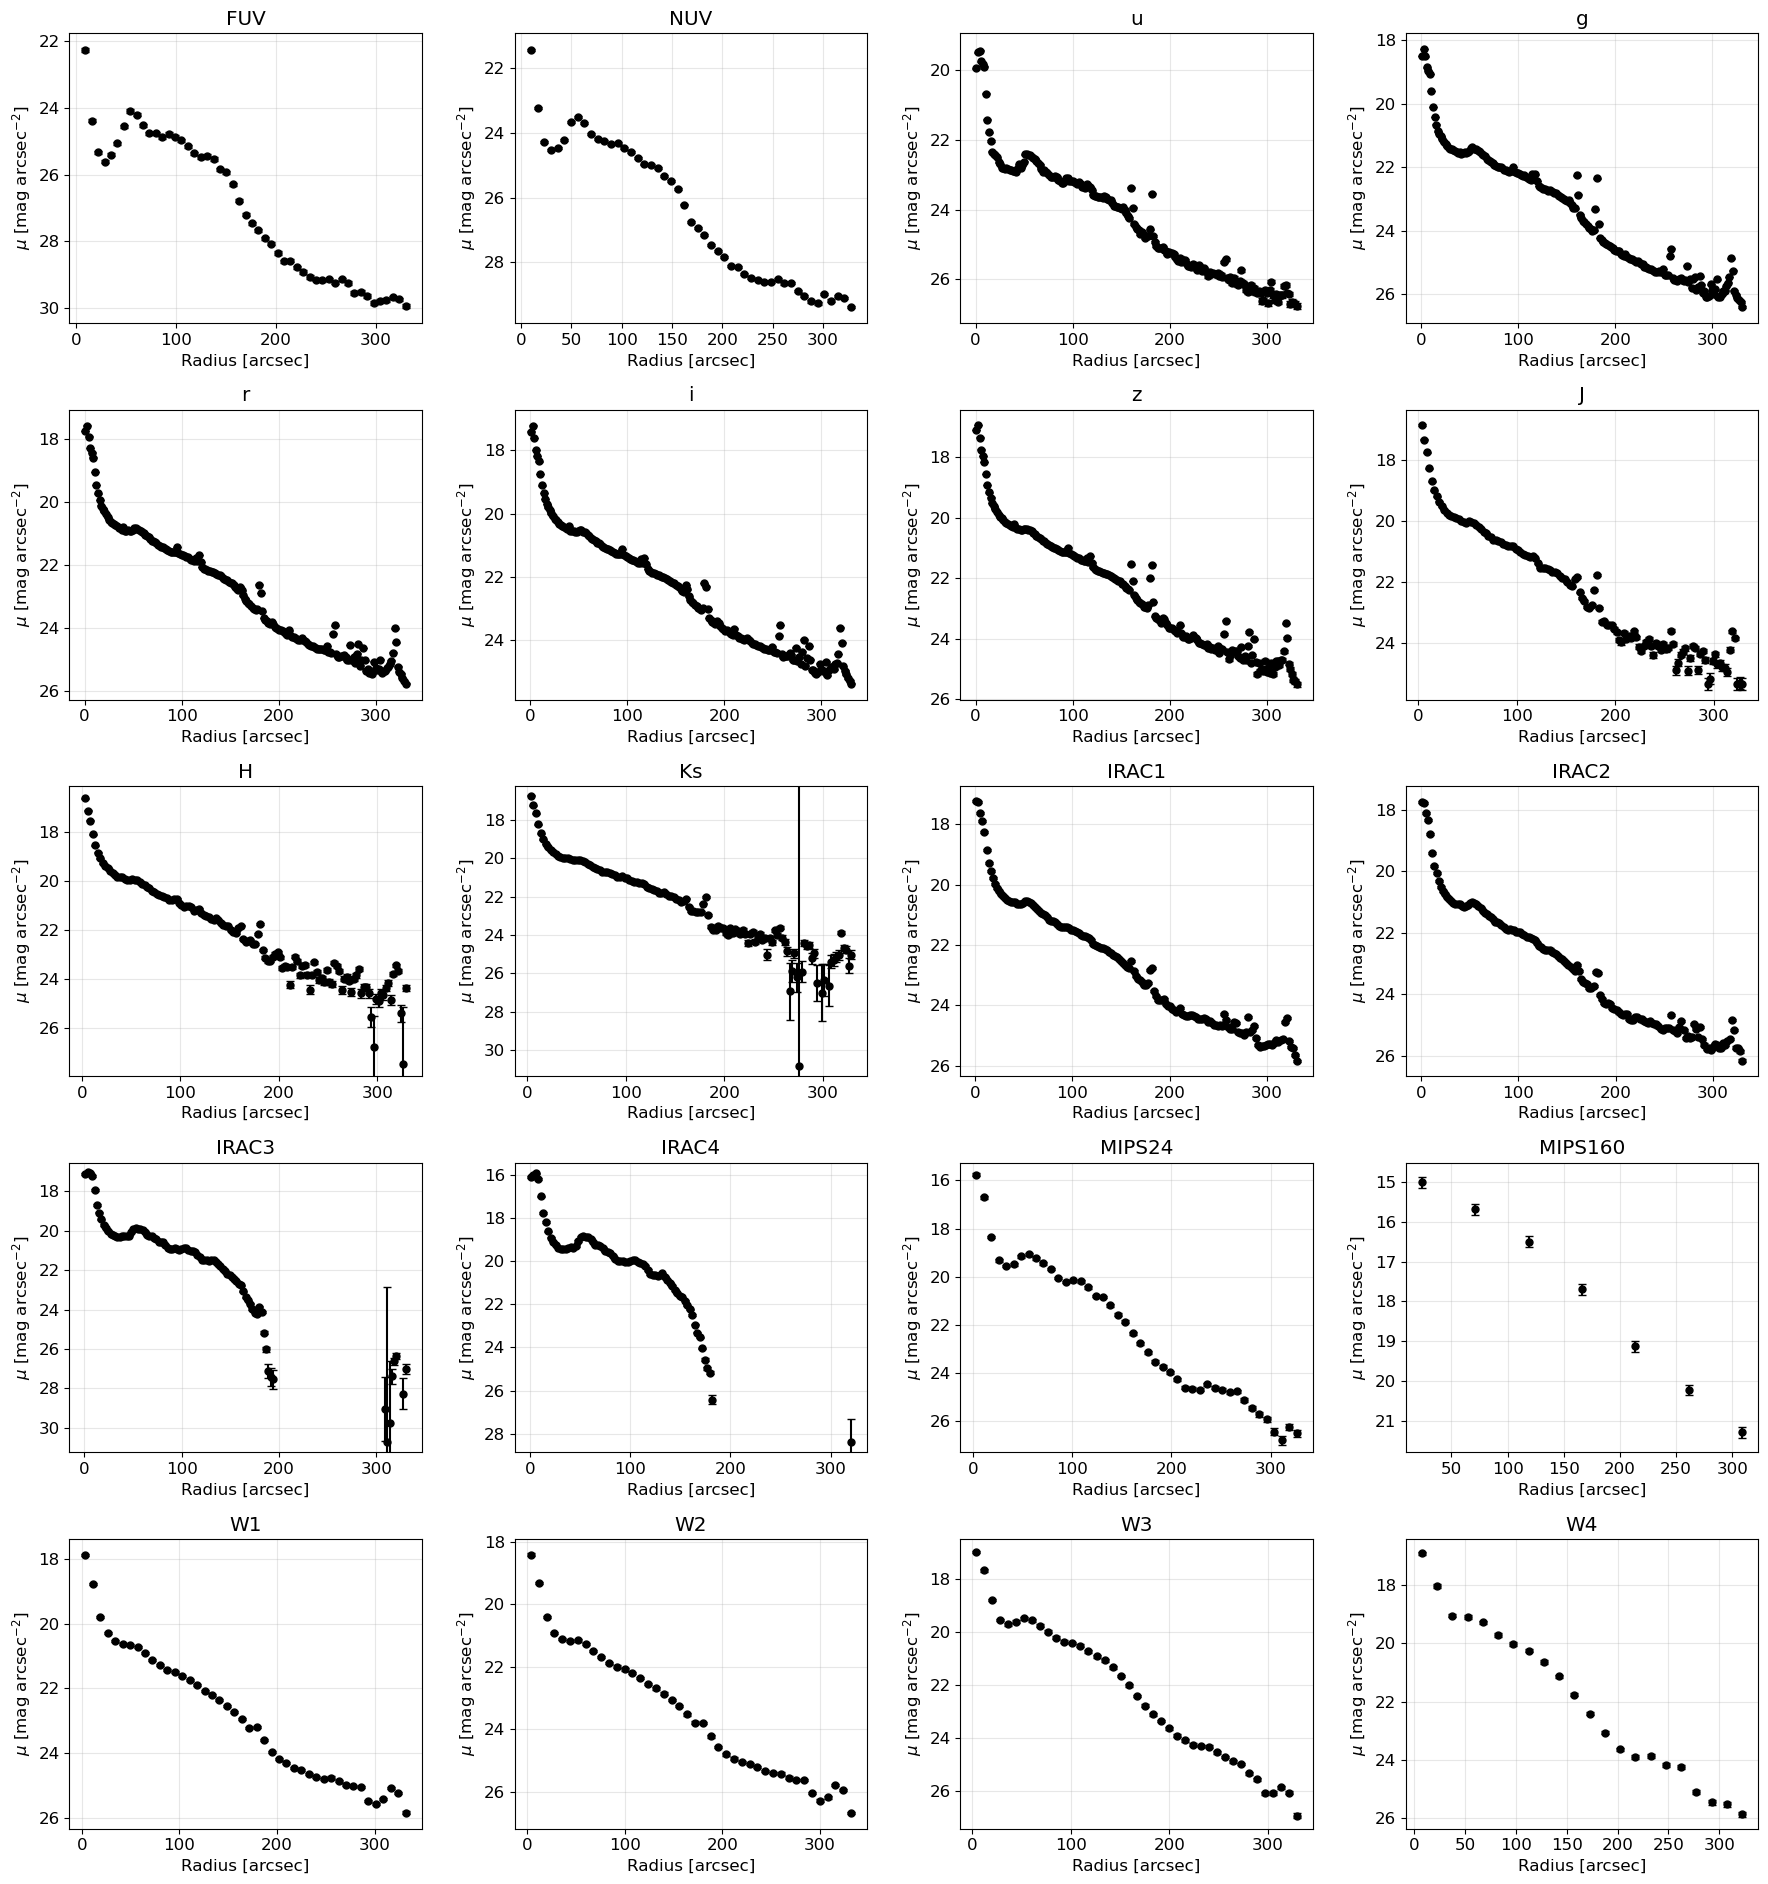

In [33]:
n_images = len(sorted_bands)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.5*ncols, 3.8*nrows))
axes = np.ravel(axes)

for ax, band in zip(axes, sorted_bands):
    prof = all_profiles[all_profiles['band'] == band]

    good = (
        np.isfinite(prof['r_mid_arcsec']) & 
        np.isfinite(prof['mu_ab_arcsec2']) & 
        np.isfinite(prof['sigma_mu_ab_arcsec2'])
    )

    ax.errorbar(prof['r_mid_arcsec'][good], prof['mu_ab_arcsec2'][good], 
                yerr=prof['sigma_mu_ab_arcsec2'][good],
                marker='o', ms=5, ls='None', color='k', capsize=3)
    
    ax.set_title(band)
    ax.set_xlabel(r'Radius [arcsec]')
    ax.set_ylabel(r'$\mu$ [mag arcsec$^{-2}$]')
    ax.grid(alpha=0.3)

    # Invert magnitude axis
    if np.count_nonzero(good) > 0:
        yvals = prof['mu_ab_arcsec2'][good]
        ax.set_ylim(np.nanmax(yvals) + 0.5, np.nanmin(yvals) - 0.5)

for ax in axes[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 8. Define the Bulge+Disk Model

We'll fit each profile with $I(r) = I_{\rm bulge}(r) + I_{\rm disk}(r).$ The disk is modeled as an exponential: $$I_{\rm disk} = I_0 \exp(-r/h),$$ where $I_0$ is the central disk surface brightness and $h$ is the disk scale length. 

Meanwhile, the bulge is described by a general Sérsic profile: $$I_{\rm bulge} = I_e \exp\left[-b_n \left(\left(\frac{r}{R_e}\right)^{1/n} - 1\right)\right],$$ where $I_e$ is the bulge surface brightness at the effective radius, $R_e$ is the effective radius, $n$ is the Sérsic index, and $b_n$ is a constant that depends on $n$. 

Importantly, we'll perform the fits in the linear units of Jy/arcsec<sup>2</sup> rather than the logarithmic magnitudes. 

In [34]:
def sersic_b_n(n):
    """
    Compute the Sérsic b_n value. 

    b_n is defined so that R_e contains half of the total light. 
    scipy.special.gammaincinv gives a numerically accurate value. 
    """
    return gammainccinv(2.0 * n, 0.5)

def sersic_intensity(r_arcsec, I_e, R_e_arcsec, n):
    """
    Sérsic surface brightness profile in linear intensity units. 

    Parameters
    ----------
    r_arcsec : array
        Radius in arcsec
    I_e : float
        Surface brightness at R_e in Jy/arcsec^2
    R_e_arcsec : float
        Effective radius in arcsec
    n : float
        Sérsic index

    Returns
    -------
    intensity : array
        Bulge intensity in Jy/arcsec^2
    """
    b_n = sersic_b_n(n)

    # Avoid division by zero
    R_e_arcsec = np.maximum(R_e_arcsec, 1e-6)

    return I_e * np.exp(-b_n * ((r_arcsec / R_e_arcsec)**(1.0/n) - 1.0))

def disk_intensity(r_arcsec, I_0, h_arcsec):
    """
    Exponential disk surface brightness profile.

    Parameters
    ----------
    r_arcsec : array
        Radius in arcsec
    I_0 : float
        Central disk surface brightness in Jy/arcsec^2
    h_arcsec : float
        Disk scale length in arcsec
    
    Returns
    -------
    intensity : array
        Disk intensity in Jy/arcsec^2
    """
    # Avoid division by zero
    h_arcsec = np.maximum(h_arcsec, 1e-6)
    return I_0 * np.exp(-r_arcsec / h_arcsec)

def bulge_disk_intensity(r_arcsec, I_e, R_e_arcsec, n, I_0, h_arcsec):
    """
    Total bulge + disk model
    """
    return (sersic_intensity(r_arcsec, I_e, R_e_arcsec, n) + disk_intensity(r_arcsec, I_0, h_arcsec))

def intensity_to_mu(intensity_jy_arcsec2):
    """
    Convert Jy/arcsec^2 to mag/arcsec^2.as_integer_ratio

    Non-positive intensities cannot be converted to magnitudes,
    so they are returned as NaN.
    """
    intensity = np.asarray(intensity_jy_arcsec2, dtype=float)
    mu = np.full_like(intensity, np.nan, dtype=float)

    good = intensity > 0
    mu[good] = -2.5 * np.log10(intensity[good] / AB_ZEROPOINT_JY)

    return mu

def sigma_intensity_to_sigma_mu(intensity_jy_arcsec2, sigma_intensity_jy_arcsec2):
    """
    Propagate uncertainty from linear intensity to magnitudes.
    """
    intensity = np.asarray(intensity_jy_arcsec2, dtype=float)
    sigma_intensity = np.asarray(sigma_intensity_jy_arcsec2, dtype=float)

    sigma_mu = np.full_like(intensity, np.nan, dtype=float)

    good = (intensity > 0) & (sigma_intensity > 0)
    sigma_mu[good] = (2.5 / np.log(10)) * (sigma_intensity[good] / intensity[good])

    return sigma_mu

## 9. Fit the Profiles

For each band, we fit five parameters: $I_e$, the bulge surface brightness at $R_e$; $R_e$, the bulge effective radius; $n$, the Sérsic index; $I_0$, the central disk surface brightness; and $h$, the disk scale length. We'll also convert $I_e$ and $I_0$ into mag/arcsec<sup>2</sup>. 

In [37]:
# The inner few pixels can be difficult sometimes.
# We'll keep the center, but change this if you want
minimum_fit_radius_arcsec = 0.0

# Do not fit beyond this radius
# Not only is the disk noisier in the outskirts, but NGC 4323 is in our binning!
maximum_fit_radius_arcsec = 300.0

fit_results = Table(
    names=['band', 'fit_success', 'fit_message', 'I_e_jy_arcsec2', 'I_e_err_jy_arcsec2', 
           'mu_e_ab_arcsec2', 'mu_e_err', 'R_e_arcsec', 'R_e_err_arcsec', 'sersic_n', 'sersic_n_err',
           'I0_disk_jy_arcsec2', 'I0_disk_err_jy_arcsec2', 'mu0_disk_ab_arcsec2', 'mu0_disk_err',
           'h_disk_arcsec', 'h_disk_err_arcsec', 'bulge_flux_model_jy', 'disk_flux_model_jy', 'bulge_to_total',
           'chi2', 'reduced_chi2', 'n_fit_points'],
    dtype=['U20', bool, 'U200', float, float, float, float, float, float, float, float, float, float,
           float, float, float, float, float, float, float, float, float, int]
)

fit_curves = {}

for band in sorted_bands:
    print(f'Fitting {band}...')

    prof = all_profiles[all_profiles['band'] == band]

    r = np.array(prof['r_mid_arcsec'], dtype=float)
    I = np.array(prof['sb_jy_arcsec2'], dtype=float)
    sigma_I = np.array(prof['sigma_sb_jy_arcsec2'], dtype=float)
    n_pix = np.array(prof['n_pix'], dtype=int)

    # Select valid bins for fitting
    good = (
        np.isfinite(r) & 
        np.isfinite(I) & 
        np.isfinite(sigma_I) & 
        (I > 0) & 
        (sigma_I > 0) & 
        (r >= minimum_fit_radius_arcsec) & 
        (r <= maximum_fit_radius_arcsec) & 
        (n_pix >= min_pixels_per_annulus)
    )

    r_fit = r[good]
    I_fit = I[good]
    sigma_fit = sigma_I[good]

    if len(r_fit) < 8:
        fit_results.add_row(
            (
                band, False, 'Too few valid radial bins for a 5-parameter fit.', 
                np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                np.nan, np.nan, np.nan, np.nan, len(r_fit)
            )
        )
        continue

    ####### Initial Guesses
    max_I = np.nanmax(I_fit)

    # Guess for disk central surface brightness
    I0_guess = max_I * 0.5

    # Guess for disk scale length
    h_guess = 80.0

    # Guess for bulge intensity near effective radius
    Ie_guess = max_I * 0.3

    # Guess for bulge effective radius
    Re_guess = 20.0

    # Guess for Sérsic index
    n_guess = 2.0

    p0 = [Ie_guess, Re_guess, n_guess, I0_guess, h_guess]

    ####### Parameter Bounds
    # We require positive intensities and radii
    # We also limit n to a reasonable range

    lower_bounds = [
        max_I * 1e-8, # I_e
        0.5,          # R_e
        0.3,          # n
        max_I * 1e-8, # I0_disk
        1.0           # h_disk
    ]

    upper_bounds = [
        max_I * 1e4,                    # I_e
        maximum_fit_radius_arcsec,      # R_e
        8.0,                            # n
        max_I * 1e4,                    # I0_disk
        5.0 * maximum_fit_radius_arcsec # h
    ]

    try:
        popt, pcov = curve_fit(bulge_disk_intensity, r_fit, I_fit, p0=p0, sigma=sigma_fit, absolute_sigma=True, 
                               bounds=(lower_bounds, upper_bounds), maxfev=50000)
        
        # Best-fit parameters
        I_e, R_e, n_sersic, I0_disk, h_disk = popt

        # Parameter uncertainties from the covariance matrix
        perr = np.sqrt(np.diag(pcov))
        I_e_err, R_e_err, n_err, I0_err, h_err = perr

        # Model evaluated at the fitted radii
        I_model_fit = bulge_disk_intensity(r_fit, *popt)

        # Goodness of fit
        residuals = I_fit - I_model_fit
        chi2 = np.sum((residuals / sigma_fit)**2)

        n_parameters = len(popt)
        degrees_of_freedom = len(r_fit) - n_parameters

        if degrees_of_freedom > 0:
            reduced_chi2 = chi2 / degrees_of_freedom
        else:
            reduced_chi2 = np.nan
        
        # Convert fitted intensities to mag/arcsec^2
        mu_e = intensity_to_mu(np.array([I_e]))[0]
        mu0_disk = intensity_to_mu(np.array([I0_disk]))[0]

        mu_e_err = sigma_intensity_to_sigma_mu(np.array([I_e]), np.array([I_e_err]))[0]
        mu0_disk_err = sigma_intensity_to_sigma_mu(np.array([I0_disk]), np.array([I0_err]))[0]

        # Integrated model fluxes in Jy
        b_n = sersic_b_n(n_sersic)

        bulge_flux = (2.0 * np.pi * I_e * R_e**2 * n_sersic * np.exp(b_n) * gamma(2.0 * n_sersic) / b_n**(2.0 * n_sersic))
        disk_flux = 2.0 * np.pi * I0_disk * h_disk**2
        bulge_to_total = bulge_flux / (bulge_flux + disk_flux)

        fit_results.add_row(
            (
                band, True, 'Fit successful', I_e, I_e_err, mu_e, mu_e_err, R_e, R_e_err, n_sersic, n_err,
                I0_disk, I0_err, mu0_disk, mu0_disk_err, h_disk, h_err, bulge_flux, disk_flux, bulge_to_total, chi2, reduced_chi2, len(r_fit)
            )
        )

        # Save smooth curves for plotting
        r_model = np.linspace(0.1, maximum_fit_radius_arcsec, 800)

        I_bulge_model = sersic_intensity(r_model, I_e, R_e, n_sersic)
        I_disk_model = disk_intensity(r_model, I0_disk, h_disk)
        I_total_model = I_bulge_model + I_disk_model

        fit_curves[band] = {
            'r_model_arcsec': r_model,
            'I_bulge_jy_arcsec2': I_bulge_model,
            'I_disk_jy_arcsec2': I_disk_model,
            'I_total_jy_arcsec2': I_total_model,
            'mu_bulge': intensity_to_mu(I_bulge_model),
            'mu_disk': intensity_to_mu(I_disk_model),
            'mu_total': intensity_to_mu(I_total_model)
        }
    
    except Exception as error:
        fit_results.add_row(
            (
                band, False, str(error), 
                np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 
                np.nan, np.nan, np.nan, np.nan, len(r_fit)
            )
        )

fit_results

Fitting FUV...
Fitting NUV...
Fitting u...
Fitting g...
Fitting r...
Fitting i...
Fitting z...
Fitting J...
Fitting H...
Fitting Ks...
Fitting IRAC1...
Fitting IRAC2...
Fitting IRAC3...
Fitting IRAC4...
Fitting MIPS24...
Fitting MIPS160...
Fitting W1...
Fitting W2...
Fitting W3...
Fitting W4...


/var/folders/nr/l3y7f0sx1tb88_zdv34l9r7r0000gp/T/ipykernel_19990/2614528034.py:76: RuntimeWarning: divide by zero encountered in log10
  mu[good] = -2.5 * np.log10(intensity[good] / AB_ZEROPOINT_JY)


band,fit_success,fit_message,I_e_jy_arcsec2,I_e_err_jy_arcsec2,mu_e_ab_arcsec2,mu_e_err,R_e_arcsec,R_e_err_arcsec,sersic_n,sersic_n_err,I0_disk_jy_arcsec2,I0_disk_err_jy_arcsec2,mu0_disk_ab_arcsec2,mu0_disk_err,h_disk_arcsec,h_disk_err_arcsec,bulge_flux_model_jy,disk_flux_model_jy,bulge_to_total,chi2,reduced_chi2,n_fit_points
str20,bool,str200,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
FUV,True,Fit successful,5.796441149223023e-06,9.369313003337735e-05,21.992162045112522,17.54973798500219,7.608903811299217,47.58892779720851,0.3000000172841836,5.480702070275506,5.948745793400322e-07,1.1720756916463356e-08,24.464002095533075,0.021392156554229724,59.19302570326067,0.34337327028934217,0.002579875486099694,0.013096231964220014,0.1645737307093464,5146.588465832582,125.52654794713615,46
NUV,True,Fit successful,1.0753250317673604e-05,2.03487241366214e-05,21.321216233357454,2.0545738137848177,8.295638383352038,6.921568029706317,0.30000000000600024,0.86227492687167,1.6334500865522423e-06,1.9018987629002123e-08,23.36730095166333,0.01264171070585948,51.99886323607922,0.16588522457434832,0.005688955025646344,0.0277506676088403,0.1701261730082822,10503.641877785125,269.3241507124391,44
u,True,Fit successful,3.3625738600072295e-05,2.6269436557913753e-07,20.083386040952146,0.008482097207959147,7.049483804949901,0.018882949218903974,0.3000000000002226,0.004677894730289974,5.628161481827357e-06,1.4678267534823177e-08,22.02414924825195,0.0028316043413361743,74.69908987275069,0.1137796172515585,0.012846345169653228,0.19732269522785492,0.06112387031579909,33691.9793154355,187.17766286353054,185
g,True,Fit successful,8.509547738275901e-05,4.444966771315325e-07,19.075299424770687,0.005671348820168548,6.930289360234606,0.014072231377452794,0.36273654231288255,0.0036006207994274,2.1902871018049063e-05,3.0558269663725744e-08,20.548813008061707,0.0015147886184111916,57.240078016618455,0.02964382702243483,0.03324098655637015,0.45090115532764713,0.06865956024198669,120044.582390932,666.9143466162889,185
r,True,Fit successful,0.00013138932581777392,8.011058086433472e-07,18.603665411786377,0.006619940964553284,6.908462608219735,0.01673942952673177,0.5077663385506637,0.004555576034800998,3.865900891253696e-05,5.572214565405679e-08,19.931938832332683,0.0015649534906673605,56.63296556954393,0.029469493247503628,0.057160875772550516,0.7790569247431479,0.06835644462160362,81362.45171437929,452.01362063544053,185
i,True,Fit successful,0.00016096604396583197,9.44450152196325e-07,18.38322994576782,0.006370435021976068,7.072985434527628,0.016977499239851652,0.5917744720059088,0.004488120991001289,5.257634591393467e-05,6.931998565393407e-08,19.598089624520515,0.0014315034038499587,57.235911145992915,0.02890287898254996,0.07770872817663065,1.0821998491645883,0.06699556300786841,80004.32406522063,444.4684670290035,185
z,True,Fit successful,0.00020365599104355897,1.3751689139832788e-06,18.127822646147543,0.007331336878030846,6.9790244101248895,0.019374558370412378,0.625802768191475,0.00523676433944809,6.168833187778476e-05,1.0783456262340038e-07,19.424558055809428,0.0018979259967093784,56.623075916354985,0.04728838454293933,0.0978034422391684,1.2427100494072352,0.07295968511219332,43570.89598219939,242.06053323444107,185
J,True,Fit successful,0.00030357500115005823,5.672337944618871e-06,17.694400608946886,0.02028712064157013,6.99774647923014,0.061667378177600554,0.6384098807712792,0.022743341697342465,9.220830235885621e-05,4.3265188950260264e-07,18.988140556461946,0.00509439831851402,52.27883917522066,0.10946133791437586,0.14771246097720042,1.583440563279447,0.08532605662669697,5978.018551297231,52.438759221905535,119
H,True,Fit successful,0.00037063890542205977,7.678104744645501e-06,17.47768811070678,0.022491962347271233,7.126830188624449,0.06988344426126523,0.7276514789380418,0.02723885888721132,9.492455763189644e-05,5.544611769352886e-07,18.9566191674964

## 10. Inspect the Fitted Parameters

In [38]:
fit_results['band', 'fit_success', 'mu_e_ab_arcsec2', 'R_e_arcsec', 'sersic_n', 'mu0_disk_ab_arcsec2', 'h_disk_arcsec', 'bulge_to_total', 'reduced_chi2']

band,fit_success,mu_e_ab_arcsec2,R_e_arcsec,sersic_n,mu0_disk_ab_arcsec2,h_disk_arcsec,bulge_to_total,reduced_chi2
str20,bool,float64,float64,float64,float64,float64,float64,float64
FUV,True,21.992162045112522,7.608903811299217,0.3000000172841836,24.464002095533075,59.19302570326067,0.1645737307093464,125.52654794713615
NUV,True,21.321216233357454,8.295638383352038,0.30000000000600024,23.36730095166333,51.99886323607922,0.1701261730082822,269.3241507124391
u,True,20.083386040952146,7.049483804949901,0.3000000000002226,22.02414924825195,74.69908987275069,0.06112387031579909,187.17766286353054
g,True,19.075299424770687,6.930289360234606,0.36273654231288255,20.548813008061707,57.240078016618455,0.06865956024198669,666.9143466162889
r,True,18.603665411786377,6.908462608219735,0.5077663385506637,19.931938832332683,56.63296556954393,0.06835644462160362,452.01362063544053
i,True,18.38322994576782,7.072985434527628,0.5917744720059088,19.598089624520515,57.235911145992915,0.06699556300786841,444.4684670290035
z,True,18.127822646147543,6.9790244101248895,0.625802768191475,19.424558055809428,56.623075916354985,0.07295968511219332,242.06053323444107
J,True,17.694400608946886,6.99774647923014,0.6384098807712792,18.988140556461946,52.27883917522066,0.08532605662669697,52.438759221905535
H,True,17.47768811070678,7.126830188624449,0.7276514789380418,18.956619167496495,54.319466715890876,0.10068266866056376,23.03909603854122


## 11. Plot the Profile Fits

Each plot shows
- points: measured surface brightness profile
- dashed line: Sérsic bulge
- dotted line: exponential disk
- solid line: total bulge+disk model

/var/folders/nr/l3y7f0sx1tb88_zdv34l9r7r0000gp/T/ipykernel_19990/2669205607.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


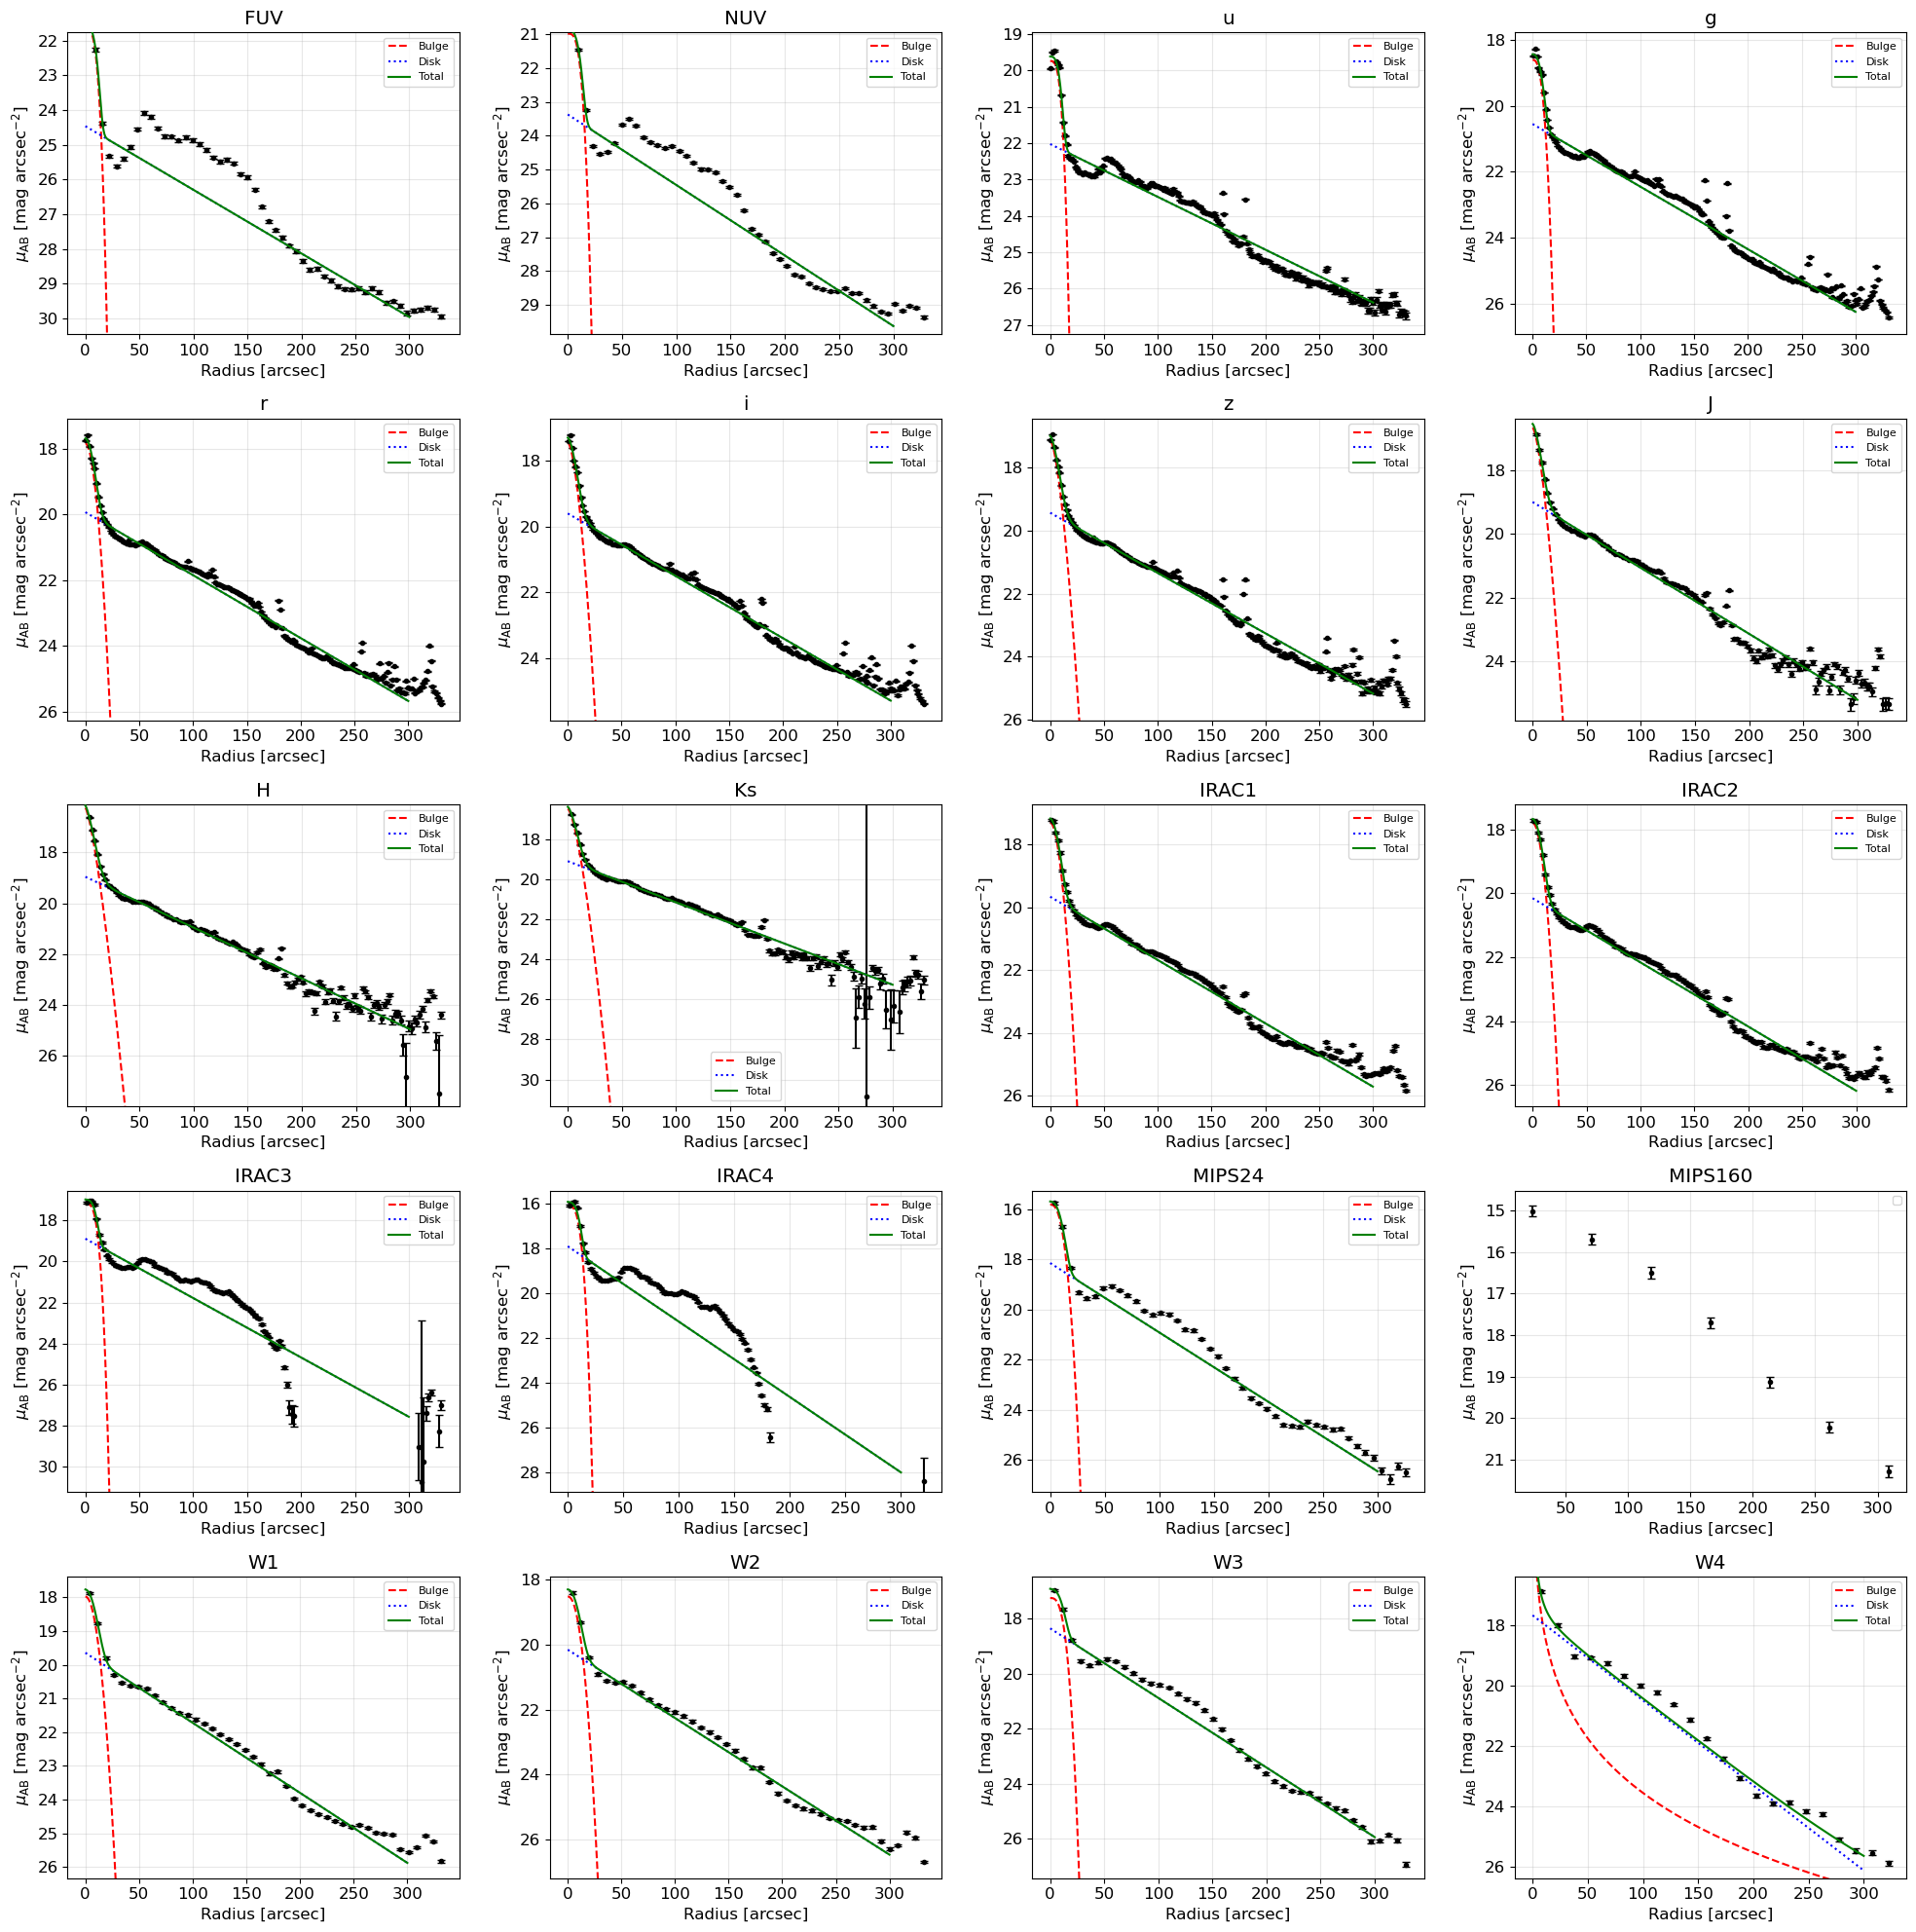

In [42]:
n_images = len(sorted_bands)
ncols = 4
nrows = int(np.ceil(n_images / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = np.ravel(axes)

for ax, band in zip(axes, sorted_bands):
    prof = all_profiles[all_profiles["band"] == band]

    good = (
        np.isfinite(prof["r_mid_arcsec"])
        & np.isfinite(prof["mu_ab_arcsec2"])
        & np.isfinite(prof["sigma_mu_ab_arcsec2"])
    )

    ax.errorbar(prof["r_mid_arcsec"][good], prof["mu_ab_arcsec2"][good],
        yerr=prof["sigma_mu_ab_arcsec2"][good],
        marker='o', ms=3, color='k', ls='None', capsize=3)
    

    if band in fit_curves:
        curves = fit_curves[band]

        ax.plot(
            curves["r_model_arcsec"],
            curves["mu_bulge"],
            linestyle="--",
            color='r',
            label="Bulge",
        )

        ax.plot(
            curves["r_model_arcsec"],
            curves["mu_disk"],
            linestyle=":",
            color='b',
            label="Disk",
        )

        ax.plot(
            curves["r_model_arcsec"],
            curves["mu_total"],
            linestyle="-",
            color='g',
            label="Total",
            zorder=10
        )

    ax.set_title(band)
    ax.set_xlabel("Radius [arcsec]")
    ax.set_ylabel(r"$\mu_{\rm AB}$ [mag arcsec$^{-2}$]")
    ax.grid(alpha=0.3)

    # Invert magnitude axis.
    plotted_mu = prof["mu_ab_arcsec2"][good]

    if len(plotted_mu) > 0:
        y_min = np.nanmin(plotted_mu)
        y_max = np.nanmax(plotted_mu)
        ax.set_ylim(y_max + 0.5, y_min - 0.5)

    ax.legend(fontsize=8)

for ax in axes[n_images:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Plot One Band 

The grid above is useful for checking everything at once, but sometimes we just want to zoom in on one band and check its fit. We'll make a larger plot for one band. Change `inspect_band` to eximate different filters. 

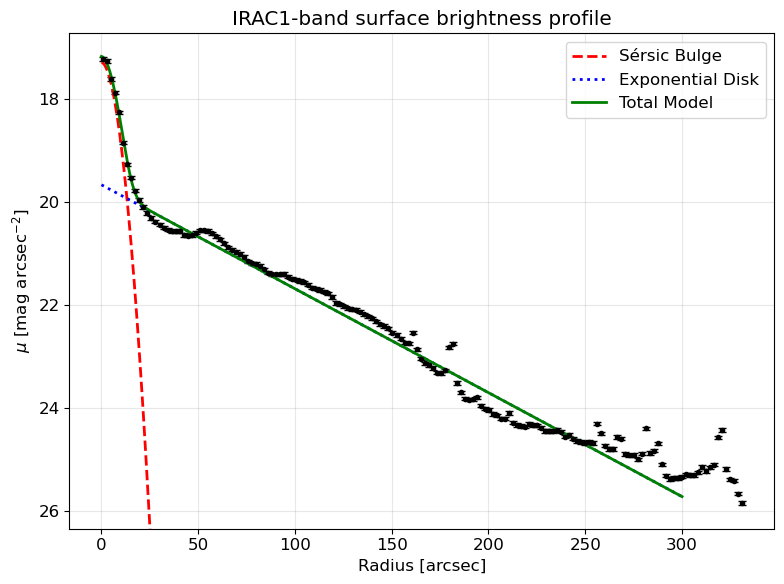

In [48]:
inspect_band = 'IRAC1'

prof = all_profiles[all_profiles['band'] == inspect_band]

good = (
    np.isfinite(prof['r_mid_arcsec']) & 
    np.isfinite(prof['mu_ab_arcsec2']) & 
    np.isfinite(prof['sigma_mu_ab_arcsec2'])
)

plt.figure(figsize=(8, 6))

plt.errorbar(prof['r_mid_arcsec'][good], prof['mu_ab_arcsec2'][good],
             yerr=prof['sigma_mu_ab_arcsec2'][good],
             marker='o', ms=3, color='k', ls='None', capsize=3)

if inspect_band in fit_curves:
    curves = fit_curves[inspect_band]

    plt.plot(curves['r_model_arcsec'], curves['mu_bulge'], 
             ls='--', lw=2, color='r', label='Sérsic Bulge')
    
    plt.plot(curves['r_model_arcsec'], curves['mu_disk'],
             ls=':', lw=2, color='b', label='Exponential Disk')
    
    plt.plot(curves['r_model_arcsec'], curves['mu_total'],
             ls='-', color='g', lw=2, label='Total Model')
    
plt.xlabel(r'Radius [arcsec]')
plt.ylabel(r'$\mu$ [mag arcsec$^{-2}$]')
plt.title(f'{inspect_band}-band surface brightness profile')
plt.grid(alpha=0.3)
plt.legend(loc='best')

plotted_mu = prof["mu_ab_arcsec2"][good]

if len(plotted_mu) > 0:
    y_min = np.nanmin(plotted_mu)
    y_max = np.nanmax(plotted_mu)
    plt.ylim(y_max + 0.5, y_min - 0.5)

plt.tight_layout()
plt.show()

## 13. Plotting Residuals

Another thing to check whenever fitting a line to data are the residuals. These show where the model predictions don't match the data. We define the residual as $$\Delta \mu = \mu_{\rm data} - \mu_{\rm model}.$$ If the model is perfect, then the residuals should scatter around zero. Real galaxies will show non-zero residuals because we didn't take into account any spiral arms, rings, bars, or star-forming regions in the fit. 

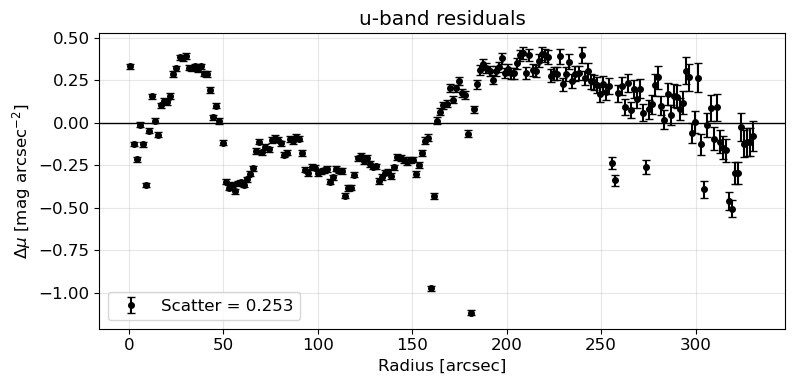

In [63]:
from astropy.stats import sigma_clipped_stats

inspect_band = 'u'

if inspect_band not in fit_curves:
    print(f'No successful fit for {inspect_band}.')
else:
    prof = all_profiles[all_profiles['band'] == inspect_band]
    fit_row = fit_results[fit_results['band'] == inspect_band][0]

    good = (
        np.isfinite(prof['r_mid_arcsec']) & 
        np.isfinite(prof['mu_ab_arcsec2']) & 
        np.isfinite(prof['sigma_mu_ab_arcsec2']) & 
        (prof['sb_jy_arcsec2'] > 0)
    )

    r_data = np.array(prof['r_mid_arcsec'][good], dtype=float)
    mu_data = np.array(prof['mu_ab_arcsec2'][good], dtype=float)
    sigma_mu_data = np.array(prof['sigma_mu_ab_arcsec2'][good], dtype=float)

    I_e = fit_row['I_e_jy_arcsec2']
    R_e = fit_row['R_e_arcsec']
    n_sersic = fit_row['sersic_n']
    I0_disk = fit_row['I0_disk_jy_arcsec2']
    h_disk = fit_row['h_disk_arcsec']

    I_model_data = bulge_disk_intensity(r_data, I_e, R_e, n_sersic, I0_disk, h_disk)

    mu_model_data = intensity_to_mu(I_model_data)

    residual_mu = mu_data - mu_model_data

    _, _, scatter = sigma_clipped_stats(residual_mu, sigma=3.0)

    plt.figure(figsize=(8,4))

    plt.axhline(0, color='k', linewidth=1)

    plt.errorbar(r_data, residual_mu, yerr=sigma_mu_data,
                 marker='o', ms=4, ls='None', color='k', capsize=3,
                 label=f'Scatter = {scatter:.3f}')
        
    plt.xlabel(r'Radius [arcsec]')
    plt.ylabel(r'$\Delta \mu$ [mag arcsec$^{-2}$]')
    plt.title(f'{inspect_band}-band residuals')
    plt.grid(alpha=0.3)
    plt.legend(loc='best')

    plt.tight_layout()
    plt.show()

## 14. Save the Profiles and Fit Results

Finally, we save the measured radial profiles, the bulge+disk fit results, and the image table used. 

In [64]:
all_profiles.write(
    output_dir / 'NGC4321_sb_profiles.ecsv', format='ascii.ecsv', overwrite=True
)

fit_results.write(
    output_dir / 'NGC4321_sb_fitresults.ecsv', format='ascii.ecsv', overwrite=True
)

image_table.write(
    output_dir / 'NGC4321_sb_imagetable.ecsv', format='ascii.ecsv', overwrite=True
)